## Testing the Model

In [1]:
import numpy as np
import tensorflow as tf
from keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [2]:
model = tf.keras.models.load_model('trained_model.keras')

In [4]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_16 (Conv2D)          (None, 128, 128, 32)      896       
                                                                 
 conv2d_17 (Conv2D)          (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 63, 63, 32)       0         
 2D)                                                             
                                                                 
 conv2d_18 (Conv2D)          (None, 63, 63, 62)        17918     
                                                                 
 conv2d_19 (Conv2D)          (None, 61, 61, 62)        34658     
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 30, 30, 62)       0         
 2D)                                                  

### Visualizing Single image of Test_set

In [6]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 3.4 MB/s eta 0:00:12
   - -------------------------------------- 1.0/40.2 MB 2.8 MB/s eta 0:00:14
   - -------------------------------------- 1.6/40.2 MB 2.5 MB/s eta 0:00:16
   -- ------------------------------------- 2.1/40.2 MB 2.5 MB/s eta 0:00:16
   -- ------------------------------------- 2.6/40.2 MB 2.4 MB/s eta 0:00:16
   -- ------------------------------------- 2.9/40.2 MB 2.3 MB/s eta 0:00:17
   --- ------------------------------------ 3.1/40.2 MB 2.3 MB/s eta 0:00:17
   --- ------------------------------------ 3.7/40.2 MB 2.2 MB/s eta 0:00:17
   ---- ----------------------------------- 4.2/40.2 MB 2.2 MB/s eta 0:00:17
   ---- ----------------------------------- 4.7/40.2 MB 2.2 MB/s eta 0:00:16
   ----- ---------------------------------- 5.2/40.2 MB 2.3 MB/s eta 0:00:16
   ----- ---------------------------------- 5.8/40.2 MB 2.3 MB/s eta 0:00:16
   ---

  You can safely remove it manually.


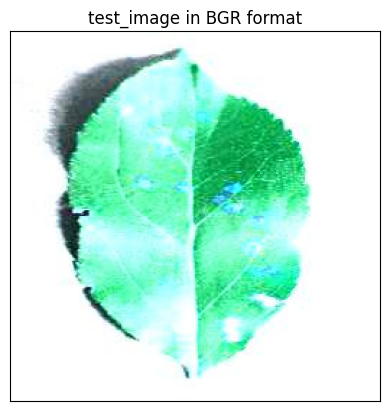

In [19]:
import cv2
image_path = "test/AppleCedarRust1.JPG"
#reading image
img = cv2.imread(image_path)

#displaying
plt.imshow(img)
plt.title("test_image in BGR format")
plt.xticks([])
plt.yticks([])
plt.show()

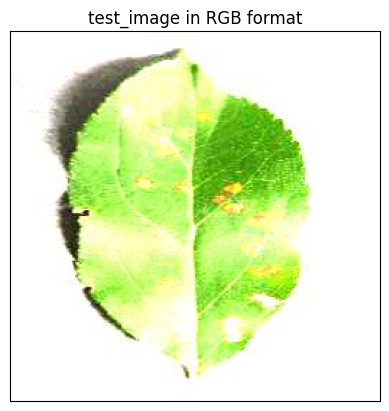

In [20]:
#converting from bgr to rgb
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("test_image in RGB format")
plt.xticks([])
plt.yticks([])
plt.show()

### Testing the model prediction on test_image

In [24]:
image = tf.keras.preprocessing.image.load_img(image_path,target_size=(128,128))
input_arr = tf.keras.preprocessing.image.img_to_array(image)
input_arr = np.array([input_arr]) #convert single image to a batch
print(input_arr.shape)

(1, 128, 128, 3)


In [51]:
prediction = model.predict(input_arr)
prediction,prediction.shape

1/1 [==============================] - 0s 65ms/step


(array([[4.18660061e-14, 4.89837730e-14, 1.00000000e+00, 4.40889013e-16,
         4.93613939e-13, 1.35197409e-10, 4.86024097e-17, 2.81481327e-13,
         7.29221848e-17, 4.54138779e-16, 5.23038580e-20, 6.36071751e-12,
         1.68819956e-15, 1.65509200e-15, 1.46955930e-14, 3.53971321e-15,
         6.88346068e-14, 1.08673215e-16, 5.05928144e-13, 5.23045756e-12,
         6.50247564e-11, 5.95666474e-13, 4.01854635e-12, 1.18740314e-14,
         3.30317538e-17, 5.16810292e-15, 1.42111732e-13, 7.22595337e-17,
         1.57310710e-11, 7.44385022e-13, 5.60460775e-11, 4.56344063e-17,
         1.00489346e-10, 2.19438758e-17, 4.95347643e-12, 3.78210164e-16,
         3.74594019e-12, 2.09777874e-15]], dtype=float32),
 (1, 38))

In [52]:
result_index = np.argmax(prediction)
result_index

2

In [53]:
class_name = ['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

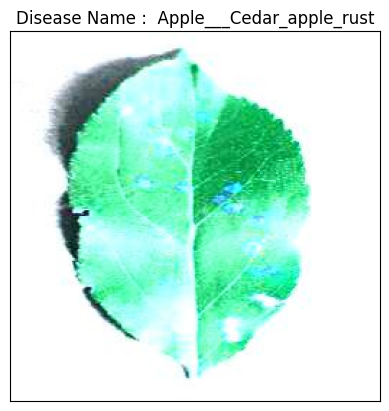

In [54]:
#Displaying the category name of disease prediction 
model_prediction=class_name[result_index]
model_prediction
plt.imshow(img)
plt.title(f"Disease Name :  {model_prediction}")
plt.xticks([])
plt.yticks([])
plt.show()

#### Testing on other Image

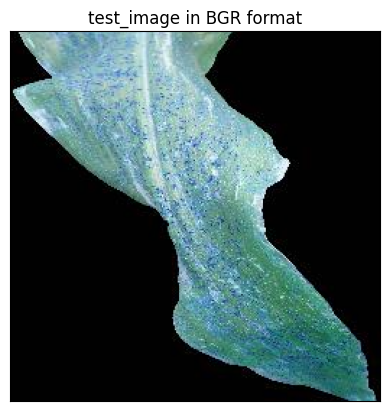

In [55]:
import cv2
image_path2 = "test/CornCommonRust3.JPG"
#reading image
img2 = cv2.imread(image_path2)

#displaying
plt.imshow(img2)
plt.title("test_image in BGR format")
plt.xticks([])
plt.yticks([])
plt.show()

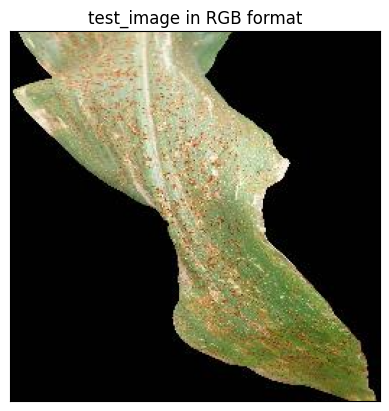

In [56]:
#converting from bgr to rgb
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.imshow(img2)
plt.title("test_image in RGB format")
plt.xticks([])
plt.yticks([])
plt.show()

In [57]:
image2 = tf.keras.preprocessing.image.load_img(image_path2,target_size=(128,128))
input_arr2 = tf.keras.preprocessing.image.img_to_array(image2)
input_arr2 = np.array([input_arr2]) #convert single image to a batch
print(input_arr2.shape)

(1, 128, 128, 3)


In [58]:
prediction2 = model.predict(input_arr2)
prediction2,prediction2.shape

1/1 [==============================] - 0s 60ms/step


(array([[5.9743773e-29, 4.8878249e-35, 7.5542591e-27, 0.0000000e+00,
         1.5581104e-30, 9.8923360e-36, 0.0000000e+00, 3.2173588e-21,
         1.0000000e+00, 4.9472631e-31, 5.3732030e-28, 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
         6.1708288e-35, 4.1879337e-33, 1.3114747e-38, 2.0047396e-31,
         1.8962690e-31, 0.0000000e+00, 8.7509789e-32, 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00, 2.7271643e-36, 0.0000000e+00,
         0.0000000e+00, 1.3928596e-32, 4.1445475e-25, 0.0000000e+00,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00, 0.0000000e+00,
         0.0000000e+00, 1.4738315e-33]], dtype=float32),
 (1, 38))

In [60]:
result_index2 = np.argmax(prediction2)
result_index2

8

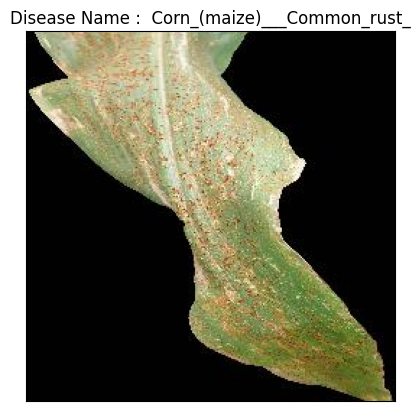

In [61]:
#Displaying the category name of disease prediction 
model_prediction2=class_name[result_index2]
model_prediction2
plt.imshow(img2)
plt.title(f"Disease Name :  {model_prediction2}")
plt.xticks([])
plt.yticks([])
plt.show()

In [62]:
model_prediction2

'Corn_(maize)___Common_rust_'